# 01 — Explore the generative model & analytical observer

Sanity-check the generative model and the analytical (Bayesian) observer with a worked example.

**Note:** the analytical-observer closed forms are `TODO(science)`. Cells that call them will raise `NotImplementedError` until you implement them in `causal_msi.generative`.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from causal_msi.config import load_config
from causal_msi import generative as gm
from causal_msi.utils import seed_everything

cfg = load_config(Path('..') / 'configs' / 'default.yaml')
rng = seed_everything(cfg.seed)
cfg.generative

GenerativeConfig(p_common=0.5, mu0=0.0, sigma0_sq=100.0, eye_mu=0.0, eye_sigma_sq=25.0, sigma2_vis_range=(1.0, 16.0), sigma2_prop_range=(4.0, 36.0), sigma2_eye_range=(1.0, 9.0), disparity_grid=[-20.0, -15.0, -10.0, -5.0, -2.0, 0.0, 2.0, 5.0, 10.0, 15.0, 20.0])

fraction common-cause trials: 0.5035


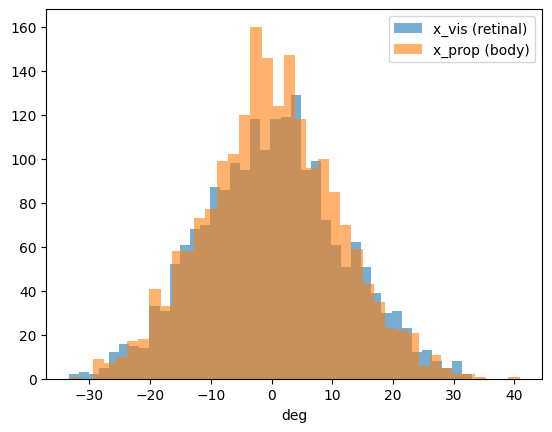

In [2]:
# Sample latents + noisy measurements (implemented).
latents = gm.sample_latents(rng, 2000, cfg.generative)
meas = gm.render_measurements(rng, latents)
print('fraction common-cause trials:', (latents.C == 1).mean())
plt.hist(meas.x_vis, bins=40, alpha=0.6, label='x_vis (retinal)')
plt.hist(meas.x_prop, bins=40, alpha=0.6, label='x_prop (body)')
plt.legend(); plt.xlabel('deg'); plt.show()

targets shape: (2000, 5)


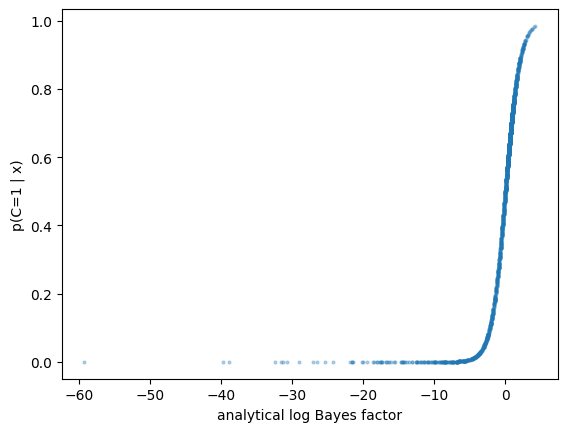

In [3]:
# Worked example: run the analytical observer (requires TODO(science)).
targets = gm.analytical_observer(meas, latents, cfg.generative)
Y = targets.to_array()
print('targets shape:', Y.shape)
plt.scatter(targets.log_bf, targets.p_common, s=4, alpha=0.3)
plt.xlabel('analytical log Bayes factor'); plt.ylabel('p(C=1 | x)'); plt.show()